In [1]:
import tensorflow as tf

In [2]:
tf.__version__

'2.21.0'

In [3]:
# Load in the dataset
from sklearn.datasets import load_breast_cancer

In [4]:
data = load_breast_cancer()
print(data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [5]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [7]:
print(data.target_names)

['malignant' 'benign']


In [8]:
data.data.shape # M - number of samples, d - number of features

(569, 30)

In [9]:
data.target.shape

(569,)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

In [12]:
N, d = X_train.shape

In [13]:
N, d

(455, 30)

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(d,)), # Input layer with shape equal to the number of features
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer with 1 neuron and sigmoid activation for binary classification
])

In [17]:
model.compile(
    optimizer='adam', # Gradient descent optimizer
    loss='binary_crossentropy', # Loss function for binary classification
    metrics=['accuracy']    # Metrics to monitor during training
)

In [18]:
r = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100)

Epoch 1/100


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3121 - loss: 1.0045 - val_accuracy: 0.4035 - val_loss: 0.9095
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4000 - loss: 0.8784 - val_accuracy: 0.4649 - val_loss: 0.7954
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4791 - loss: 0.7735 - val_accuracy: 0.6053 - val_loss: 0.6990
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5736 - loss: 0.6847 - val_accuracy: 0.7018 - val_loss: 0.6191
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6659 - loss: 0.6125 - val_accuracy: 0.7544 - val_loss: 0.5565
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7385 - loss: 0.5542 - val_accuracy: 0.7982 - val_loss: 0.5055
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8000 - loss: 0.5081 - val_accuracy: 0.8509 - val_loss: 0.4645
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8484 - loss: 0.4699 - val_accuracy: 0.8596 - val_loss: 0.

In [19]:
print(f'Training score: {model.evaluate(X_train, y_train)}')
print(f'Test score: {model.evaluate(X_test, y_test)}')

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9670 - loss: 0.1021 
Training score: [0.10208030790090561, 0.9670329689979553]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9561 - loss: 0.0938 
Test score: [0.09380531311035156, 0.9561403393745422]


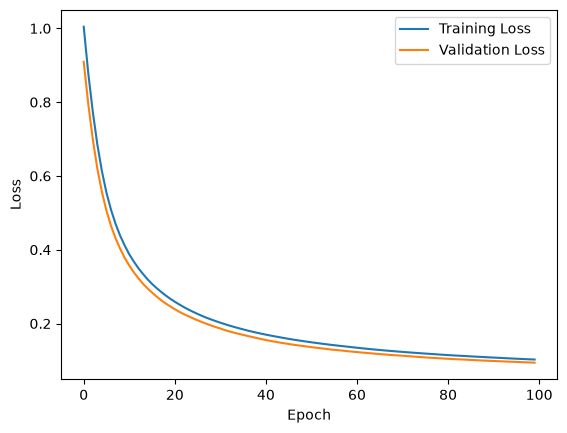

In [20]:
import matplotlib.pyplot as plt

plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

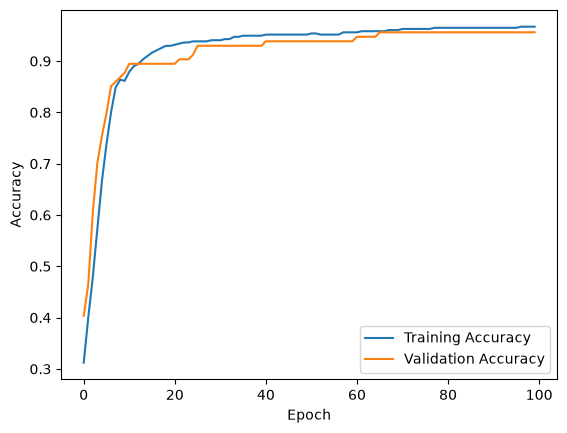

In [21]:
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [22]:
P = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [23]:
import numpy as np
P = np.round(P).flatten()
print(P)

[1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0.
 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0.]


In [24]:
print('Manually calculated accuracy: ', np.mean(P == y_test))
print('Model calculated accuracy: ', model.evaluate(X_test, y_test))

Manually calculated accuracy:  0.956140350877193
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9561 - loss: 0.0938 
Model calculated accuracy:  [0.09380531311035156, 0.9561403393745422]


In [26]:
w, b = model.layers[0].get_weights()
w, b

(array([[-0.36989152],
        [-0.09439883],
        [-0.2792783 ],
        [-0.6614483 ],
        [-0.09324201],
        [-0.5280905 ],
        [-0.2805981 ],
        [-0.5672669 ],
        [-0.18376192],
        [-0.04977451],
        [-0.31291786],
        [ 0.01922029],
        [-0.25581378],
        [-0.27041486],
        [-0.10904831],
        [ 0.01108721],
        [ 0.20112899],
        [ 0.09878256],
        [ 0.43141878],
        [-0.00880093],
        [-0.74747694],
        [-0.9171033 ],
        [-0.26066276],
        [-0.60111845],
        [-0.09068684],
        [-0.08583614],
        [-0.03528035],
        [-0.28669575],
        [-0.64442337],
        [ 0.12662612]], dtype=float32),
 array([0.4784742], dtype=float32))

In [28]:
model.save('linearClassification.keras')

In [29]:
model_load = tf.keras.models.load_model('linearClassification.keras')
print(model.layers)

[<Dense name=dense, built=True>]


e:\AI and ML\Deep-Learning\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [30]:
model.evaluate(X_test, y_test)  

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9561 - loss: 0.0938 


[0.09380531311035156, 0.9561403393745422]